# Welcome to Australian CPI Forecasting

## Why this exists

Most university coursework ends the same way: a notebook cleans some data, fits a
model, prints a forecast, gets a mark, and is never opened again. Mine was no
exception, [the original assignment](https://github.com/JuanVu1810/CPI-Forecast/blob/main/notebooks/cpi_forecast_V1.ipynb)
was a single notebook that cleaned ABS CPI data (even this data was given, not being extracted) and fit a quarterly SARIMA
model. It did exactly what it was asked to do, and then it was done.

This Jupyter book is that notebook’s afterlife. The original question is still being kept (which simply just uses the historical CPI data and builds a model to forecast the next 8 quarters), while everything downstream of it is new: reproducible data retrieval and ETL, a DuckDB analytics layer, SARIMA/Elastic Net/Ensemble competing on genuine walk-forward evidence, a structural VAR for attributing why CPI moved when it did, a scenario engine, an RBA policy-action classifier, an illustrative credit-stress test, and a FastAPI + Streamlit app to serve all of it (with a live Cloud Run deployment behind it too).

## The question, stated with appropriate gravity

Officially, and for the record:

**Can external macroeconomic features, including unemployment, cash rate,
producer prices, commodity/oil prices, and business inflation expectations
improve Australian CPI forecasts with comparison to a seasonal-naive baseline and
the RBA's own published forecasts, for both headline (`cpi_yoy`) and
trimmed-mean (`trimmed_mean_cpi_yoy`) inflation?**

It's the sentence every chapter after this one exists to answer.

## How this book is organised

This book follows the CRISP-DM structure used throughout the project:
Business Understanding, Data Understanding, Data Preparation, Modeling,
Evaluation, Deployment, and Conclusion. Every equation is taken from the
code that actually runs, and every one is followed by a plain-English,
step-by-step explanation. No background in time series or classification is assumed (hopefully).

**Two ways to read it.** If you want the results in plain English, start with [Key Findings](00_results_at_a_glance). If you want to know how they were made, follow the chapters in order, or use the "Full method" links on the Key Findings page to jump straight to the chapter behind a result.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

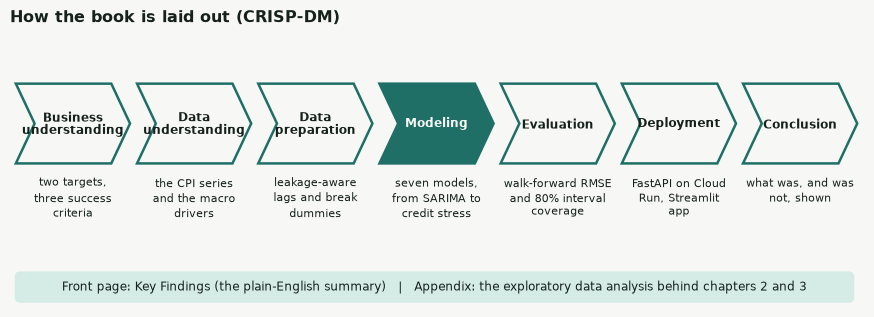

In [2]:
import textwrap
from matplotlib.patches import FancyBboxPatch, Polygon

stages = [
    ("1", "Business\nunderstanding", "two targets, three success criteria"),
    ("2", "Data\nunderstanding", "the CPI series and the macro drivers"),
    ("3", "Data\npreparation", "leakage-aware lags and break dummies"),
    ("4", "Modeling", "seven models, from SARIMA to credit stress"),
    ("5", "Evaluation", "walk-forward RMSE and 80% interval coverage"),
    ("6", "Deployment", "FastAPI on Cloud Run, Streamlit app"),
    ("7", "Conclusion", "what was, and was not, shown"),
]
fig, ax = plt.subplots(figsize=(9.2, 3.3))
ax.set_xlim(0, 14.6)
ax.set_ylim(-0.6, 4.6)
ax.axis("off")
w, gap, top = 1.95, 0.12, 3.6
for i, (num, name, blurb) in enumerate(stages):
    x = 0.1 + i * (w + gap)
    tip = 0.32
    face = ACCENT if num == "4" else PAPER
    edge = ACCENT
    ax.add_patch(Polygon([(x, top), (x + w - tip, top), (x + w, top - 0.75), (x + w - tip, top - 1.5), (x, top - 1.5),
                          (x + tip, top - 0.75)], closed=True, facecolor=face, edgecolor=edge, linewidth=1.8))
    ax.text(x + w / 2, top - 0.75, name, ha="center", va="center", fontsize=8.6, fontweight="bold",
            color=PAPER if num == "4" else INK, linespacing=1.15)
    ax.text(x + w / 2, top - 1.72, "\n".join(textwrap.wrap(blurb, 17)), ha="center", va="top", fontsize=8, linespacing=1.35)
ax.add_patch(FancyBboxPatch((0.1, -0.5), 14.3, 0.55, boxstyle="round,pad=0.02,rounding_size=0.1", facecolor=ACCENT_SOFT,
                            edgecolor="none", alpha=0.6))
ax.text(7.25, -0.225, "Front page: Key Findings (the plain-English summary)   |   Appendix: the exploratory data analysis behind chapters 2 and 3",
        ha="center", va="center", fontsize=8.6)
ax.set_title("How the book is laid out (CRISP-DM)", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()

```{admonition} Static book vs. the live app
:class: note
This book is a static, pinned snapshot, good for reading end to end. A handful
of sections (the Ensemble's Monte-Carlo reveal, the Scenario Engine, and the RBA
Policy Classifier's live refresh) are genuinely interactive and can't be replayed
on a static page; those sections show a fixed example plus a callout box telling
you how to reach the live version instead.

- **Live, interactive app:** run `streamlit run app/streamlit_app.py` from the
  project root.
- **Live forecast/scenario API:** <https://cpi-forecast-api-887232555982.asia-southeast1.run.app/docs>
  (verified live 2026-08-29; serves `/forecast/all`, `/forecast/trimmed-mean/all`,
  and `/forecast/scenario` from baked local MLflow runs; a redeploy step is not
  wired into CI, so it may lag the repository).
- **Source code:** <https://github.com/JuanVu1810/CPI-Forecast>
```